# Support vector machines for concrete strength classification

In this notebook, we repeat the concrete strength classification exercise (already seen in the linear discriminant analysis and logistic regression notebooks) with support vector machines (SVMs). Rather than predicting the compressive strength from a regression perspective, we discretize the target variable into three strength classes:
- Low strength: $f_c < 25\ \text{MPa}$
- Medium strength: $25 \leq f_c \leq 40\ \text{MPa}$
- High strength: $f_c > 40\ \text{MPa}$
  
We will then reformulate the original regression problem as a multiclass classification problem and address it with SVMs. Unlike Linear Discriminant Analysis and Logistic Regression, SVMs do not estimate class probabilities. Instead, they determine the decision boundaries by solving an optimization problem that maximizes the separation margin between classes. Only a subset of the training observations, known as **support vectors**, determines the final classifier.

We first consider a linear SVM and then investigate the effect of nonlinear kernels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

### Load data

The dataset contains:
- Input variables describing the concrete composition
- One target variable corresponding to the concrete compressive strength

In [2]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)
# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

# Display the first rows of the dataset
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values # All columns except last → input features
y = df.iloc[1:, -1].values # Last column → target

N, d = X.shape

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print(f"Number of samples: {N}")
print(f"Number of input features: {d}")

Input shape: (1029, 8)
Target shape: (1029,)
Number of samples: 1029
Number of input features: 8


### Convert compressive strength into strength classes

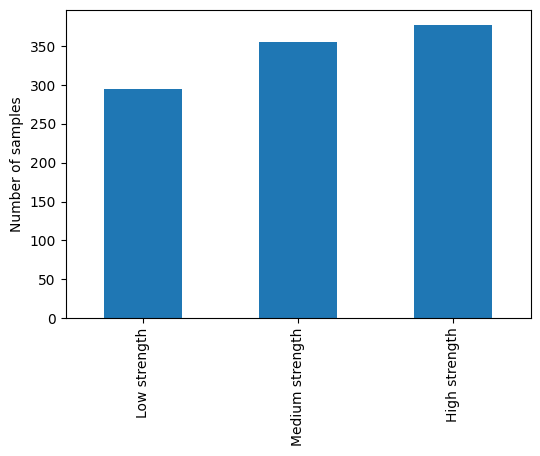

In [4]:
# Strength intervals (MPa)
bins = [0, 25, 40, np.inf]

class_names = ["Low strength", "Medium strength", "High strength",]

y_class = pd.cut(y,bins=bins,labels=class_names)

plt.figure(figsize=(6,4))
y_class.value_counts().sort_index().plot.bar()

plt.ylabel("Number of samples")

plt.show()

### Split and normalize the data

SVMs rely on distances and inner products between observations. Consequently, all variables should be standardized before training so that features measured on different scales contribute equally to the optimization problem.

- Split using 80% train and 20% test
- Compute normalization statistics from training data
- Consistently apply normalization to the test data

In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=4, stratify=y_class)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Linear SVM

We first train a linear SVM using Scikit-learn. The parameter `C` controls the trade-off between maximizing the margin and correctly classifying the training observations.

In [6]:
svm = SVC(kernel="linear", C=1.0)

svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Prediction and visualization

The performance of a classifier can be evaluated by comparing its predictions with the ground-truth labels. A convenient way to summarize the classification results is with a confusion matrix, which reports the number of correctly and incorrectly classified samples.

The confusion matrix is often complemented by the accuracy metric, which measures the proportion of correctly classified samples.

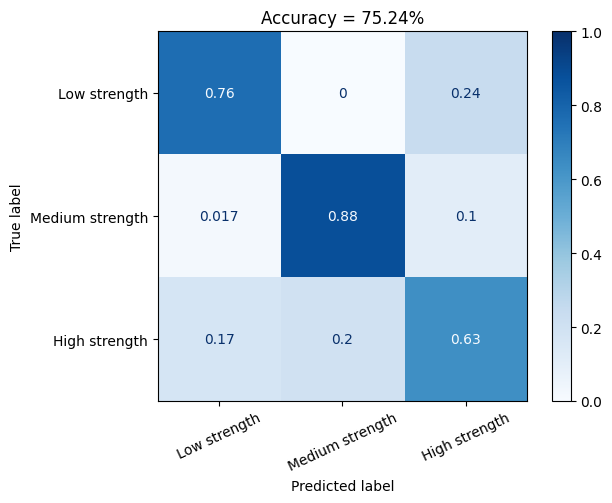

In [7]:
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low strength", "Medium strength", "High strength"])
disp.plot(cmap='Blues', xticks_rotation=25)
disp.im_.set_clim(0, 1)
plt.title(f"Accuracy = {accuracy:.2%}")
plt.show()

### Support vectors

Only a subset of the training observations, called support vectors, determines the optimal separating hyperplanes.

In [8]:
print("Support vectors per class:", svm.n_support_)
print("Total support vectors:", svm.n_support_.sum())
print(f"Fraction of support vectors: "
      f"{100*svm.n_support_.sum()/len(X_train):.1f}%")

# To access the support vectiors
# svm.support_vectors_[:5] # Only inspect the first five support vectors

Support vectors per class: [171 123 264]
Total support vectors: 558
Fraction of support vectors: 67.8%


The number of support vectors is not specified by the user but is automatically determined during the optimization process. A training observation becomes a support vector if it contributes to defining the optimal separating hyperplane (all those observations for which the corresponding Lagrange multiplier is $\alpha_i>0$). In particular:

- Points lying exactly on the margin are support vectors.
- Points inside the margin are also support vectors.
- Misclassified observations are support vectors as well.
- Observations that are sufficiently far from the decision boundary have no influence on the classifier and are not support vectors.

Consequently, the number of support vectors provides useful information about the complexity of the classification problem.

As a rule of thumb:
- 5–20% of the training observations are support vectors for a relatively easy classification problem with well-separated classes.
- 20–50% is common for moderately difficult problems.
- More than 50% may indicate substantial overlap between classes or a particularly flexible decision boundary.

The regularization parameter `C` also influences the number of support vectors.

### Influence of the penalty parameter `C`

The parameter `C` controls the trade-off between maximizing the separation margin and minimizing classification errors. Small values produce wider margins and stronger regularization. Large values attempt to correctly classify every training observation.

In [9]:
# Sample C values
C_values = [0.01,0.1,1,10,100]

for C in C_values:

    svm = SVC(kernel="linear",C=C)

    svm.fit(X_train_scaled,y_train)

    acc = accuracy_score(y_test, svm.predict(X_test_scaled))
    print(f"C = {C:>4}:   Accuracy = {acc:.2%}")

C = 0.01:   Accuracy = 68.93%
C =  0.1:   Accuracy = 72.33%
C =    1:   Accuracy = 75.24%
C =   10:   Accuracy = 76.21%
C =  100:   Accuracy = 76.21%


### Nonlinear kernels

Linear SVMs construct hyperplanes in the original feature space. Kernel methods implicitly transform the observations into higher-dimensional spaces, allowing nonlinear decision boundaries to be constructed. Let us compare the linear kernel against the RBF kernel.


C = 0.01:
Support vectors per class: [286 236 285]
Total support vectors: 807
Fraction of support vectors: 98.1%


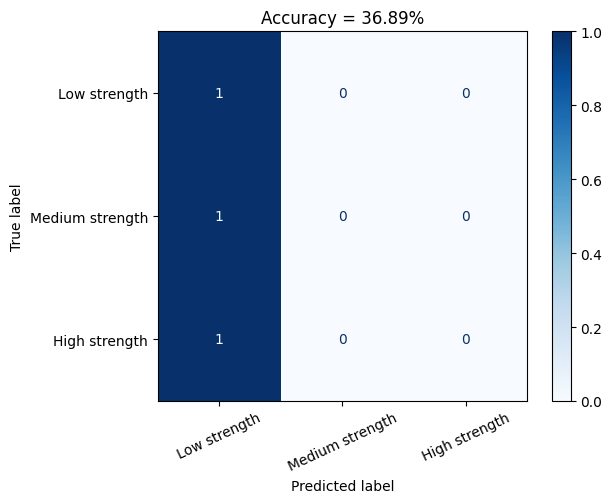


C =  0.1:
Support vectors per class: [249 226 284]
Total support vectors: 759
Fraction of support vectors: 92.2%


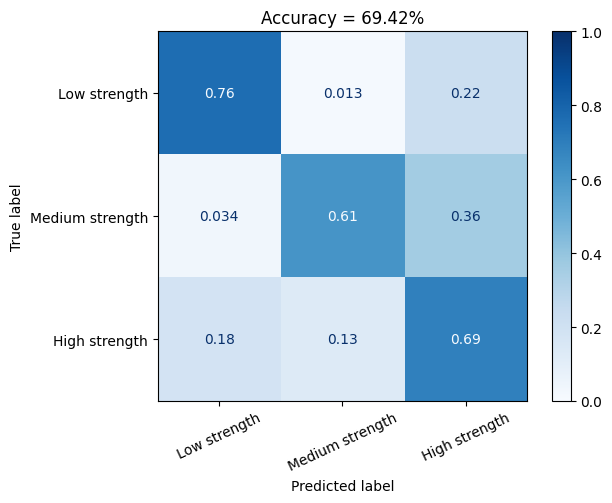


C =    1:
Support vectors per class: [175 152 266]
Total support vectors: 593
Fraction of support vectors: 72.1%


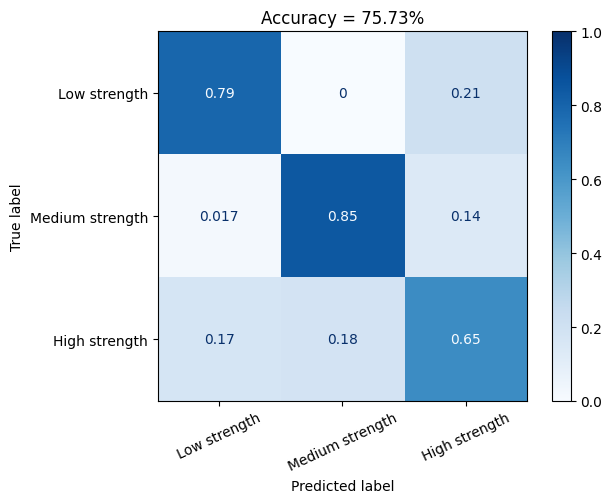


C =   10:
Support vectors per class: [120 104 206]
Total support vectors: 430
Fraction of support vectors: 52.2%


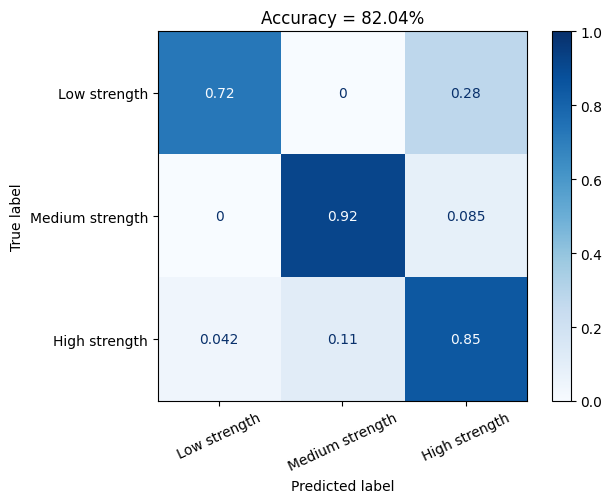


C =  100:
Support vectors per class: [ 88  80 152]
Total support vectors: 320
Fraction of support vectors: 38.9%


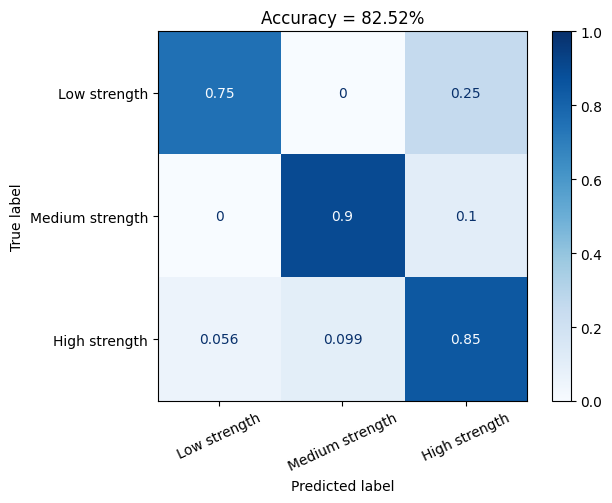

In [10]:
# Sample C values
C_values = [0.01,0.1,1,10,100]

for C in C_values:

    svm = SVC(kernel="rbf",C=C,gamma="scale")

    svm.fit(X_train_scaled,y_train)

    y_pred = svm.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nC = {C:>4}:")
    print("Support vectors per class:", svm.n_support_)
    print("Total support vectors:", svm.n_support_.sum())
    print(f"Fraction of support vectors: "
          f"{100*svm.n_support_.sum()/len(X_train):.1f}%")

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low strength", "Medium strength", "High strength"])
    disp.plot(cmap='Blues', xticks_rotation=25)
    disp.im_.set_clim(0, 1)
    plt.title(f"Accuracy = {acc:.2%}")
    plt.show()

### Exercises

- Compare the classification accuracy obtained using LDA, Logistic Regression and SVM.

- Compare the number of support vectors with the total number of training observations. What does this indicate about the SVM learning principle?

- Investigate how the parameter gamma affects the decision boundary when using the RBF kernel.